In [1]:
import pandas as pd
import numpy as np

import re

import string

import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score

import nltk

from nltk.corpus import stopwords

from nltk.stem import WordNetLemmatizer

from nltk.tokenize import word_tokenize


In [6]:
nltk.download('punkt') 
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SFL-3\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\SFL-3\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SFL-3\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
df = pd.read_csv('emails.csv')

In [8]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [9]:
df.shape

(5728, 2)

In [10]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [11]:
df['spam'].value_counts()

spam
0    4360
1    1368
Name: count, dtype: int64

In [14]:
non_spam = df[df['spam']==0].sample(n=1368,random_state=42)

In [16]:
non_spam.shape

(1368, 2)

In [19]:
spam = df[df['spam']==1]

In [20]:
df_balanced = pd.concat([non_spam,spam])

In [23]:
df_balanced['spam'].value_counts()

spam
0    1368
1    1368
Name: count, dtype: int64

In [28]:
df_balanced['text'][101]

"Subject: tell these cam sluts what to do  to be removed please click here or simply respond to this email . your address will be removed and blocked from ever being added again .  please scroll down to the bottom of this email for more details .  all these shows are live right now !  ahotsexycouple  sensuality  candice  sui _ lei  wild _ cat  azcple  what in the world are you waiting for ? click now and tell any of these women what to do for you live on camera . don ' t be shy , just signup for free and tell them what you want and you will get .  click here for the free live show !  this is our central mailing for all of our affiliate sites . if you have a question on how you got on , please email us and we will be glad to help .  the fastest way to get off our list is to click this link . if you do not have access to it , please respond to this email .  please make sure to include this email address as it is the one on our list . zzzz @ example . com"

In [29]:
stop_words = set(stopwords.words('english'))

In [30]:
lemma = WordNetLemmatizer()

In [32]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'^subject:\s*', '', text)

    text = re.sub(r'\S+@\S+', '', text)

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  

    text = re.sub(r'\d+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation)) 

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]  


    tokens = [lemma.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

In [31]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [33]:
df_balanced['clean_text']=df_balanced['text'].apply(clean_text)

In [34]:
df_balanced

,text,spam,clean_text
1547,Subject: interview schedule for jinbaek kim i...,0,interview schedule jinbaek kim see went happy ...
2730,"Subject: re : wednesday meeting eric , i thi...",0,wednesday meeting eric think skip meeting disc...
4843,Subject: re : london research group i ' d do ...,0,london research group soon possible call exact...
2856,"Subject: re : congratulations vince , thanks ...",0,congratulation vince thanks note congratulatio...
3804,Subject: osman sezgen steve kromer is request...,0,osman sezgen steve kromer requesting osman spe...
...,...,...,...
1363,Subject: are you ready to get it ? hello ! v...,1,ready get hello viagra med struggle men erecti...
1364,Subject: would you like a $ 250 gas card ? do...,1,would like gas card let current high price gas...
1365,"Subject: immediate reply needed dear sir , i...",1,immediate reply needed dear sir dr james alabi...
1366,Subject: wanna see me get fisted ? fist bang...,1,wan na see get fisted fist bang show everythin...


In [35]:
X = df_balanced['clean_text']
y = df_balanced['spam']

In [36]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20, random_state=42)

In [37]:
X_train

1797    visible red mike robert hou ect jose marquez c...
1120    happy size sexual performance experience power...
950     lock client gain winning combination market ch...
4277    energy derivative course dear vince grant good...
3913    lng meeting bjorn lng meeting held tomorrow th...
                              ...                        
270     iso q automated reply administrator vakantie t...
4371    powerisk cocktail info forwarded iona maclean ...
2432    new value lab fyi ajo forwarded amy oberg hou ...
3018    craig thanks feedback received similar report ...
2719    employment authorization hi vince last evening...
Name: clean_text, Length: 2188, dtype: object

In [40]:
ngram_ranges = [(1,1),(2,2),(3,3),(1,2),(1,3)]
acc_scores=[]


for ngram in ngram_ranges:
    print(f"\n Now let's try with n-gram range:{ngram}.............")

    cvec = CountVectorizer(ngram_range=ngram)

    X_train_vec = cvec.fit_transform(X_train)
    X_test_vec = cvec.transform(X_test)

    model = MultinomialNB()
    model.fit(X_train_vec,y_train)

    y_pred = model.predict(X_test_vec)


    acc=accuracy_score(y_test,y_pred)
    acc_scores.append(acc)

    print(f"Accuracy for n-gram {ngram} :{acc:4f}")



 Now let's try with n-gram range:(1, 1).............
Accuracy for n-gram (1, 1) :0.987226

 Now let's try with n-gram range:(2, 2).............
Accuracy for n-gram (2, 2) :0.976277

 Now let's try with n-gram range:(3, 3).............
Accuracy for n-gram (3, 3) :0.950730

 Now let's try with n-gram range:(1, 2).............
Accuracy for n-gram (1, 2) :0.985401

 Now let's try with n-gram range:(1, 3).............
Accuracy for n-gram (1, 3) :0.985401


C:\Users\SFL-3\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


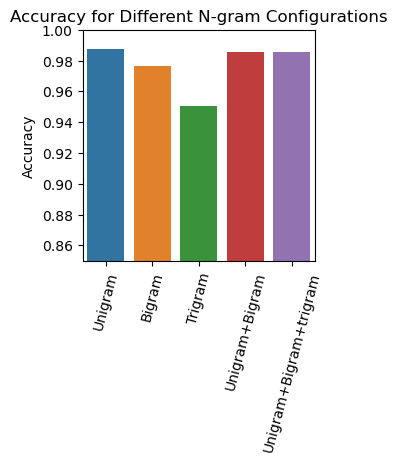

In [57]:
import seaborn as sns

labels = ['Unigram', 'Bigram', 'Trigram', 'Unigram+Bigram','Unigram+Bigram+trigram']

plt.figure(figsize=(3, 3))
sns.barplot(x=labels, y=acc_scores)
plt.title("Accuracy for Different N-gram Configurations")
plt.ylabel("Accuracy")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=75)
plt.show()
